In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.misc import derivative

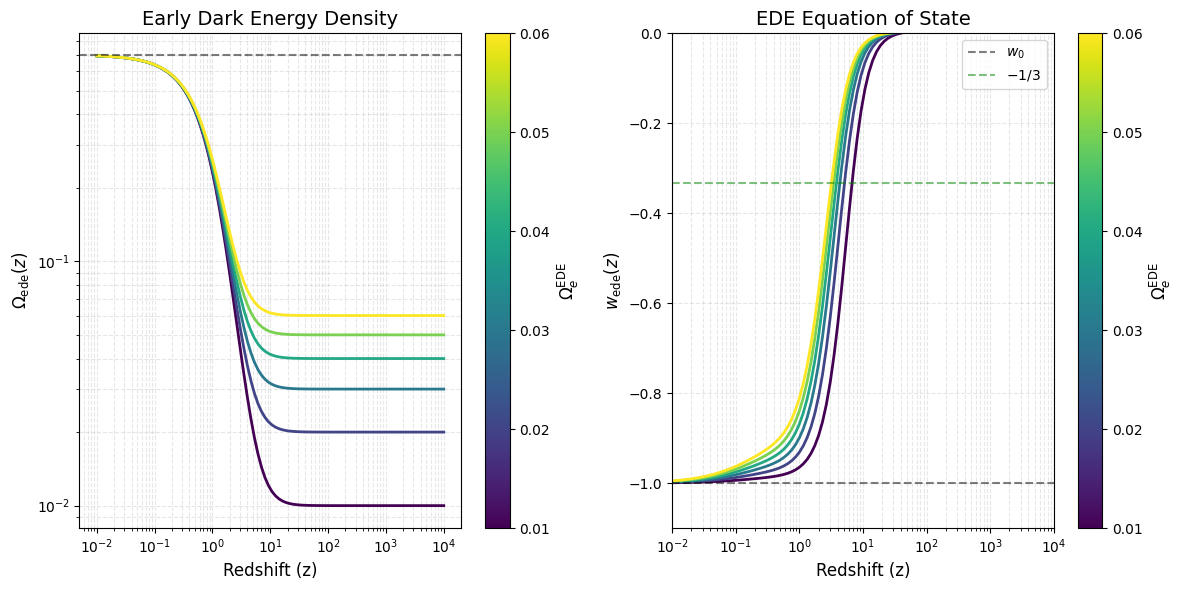

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants and parameters
Omega_ede0 = 0.7       
Omega_eEDE_values = np.linspace(0.01, 0.06, 6)  # Array from 0.01 to 0.06 in 6 steps
Omega_m0 = 0.3         
w0 = -1.0            
a_eq = 1/3400          

z = np.logspace(-2, 4, 100)  
a = 1/(1 + z)           

def Omega_ede(a, Omega_eEDE):
    term1 = (Omega_ede0 - Omega_eEDE * (1 - a**(-3*w0)))
    term2 = (Omega_ede0 + Omega_m0 * a**(3*w0))
    term3 = Omega_eEDE * (1 - a**(-3*w0))
    return term1/term2 + term3

def dlnOmega_dlna(a, Omega_eEDE):
    eps = 1e-6
    a_plus = a * (1 + eps)
    a_minus = a * (1 - eps)
    Omega_plus = Omega_ede(a_plus, Omega_eEDE)
    Omega_minus = Omega_ede(a_minus, Omega_eEDE)
    return (np.log(Omega_plus) - np.log(Omega_minus)) / (2 * eps)

def w_ede(a, Omega_eEDE):
    term1 = -1/(3*(1 - Omega_ede(a, Omega_eEDE))) * dlnOmega_dlna(a, Omega_eEDE)
    term2 = a_eq/(3*(a + a_eq))
    return term1 + term2

# Create plot
fig = plt.figure(figsize=(12, 6))

# Color map for different Omega_eEDE values
cmap = plt.cm.viridis
norm = plt.Normalize(vmin=min(Omega_eEDE_values), vmax=max(Omega_eEDE_values))

# Plot Omega_ede(z) for all values
ax1 = plt.subplot(1, 2, 1)
for i, Omega_eEDE in enumerate(Omega_eEDE_values):
    Omega_ede_vals = np.array([Omega_ede(ai, Omega_eEDE) for ai in a])
    plt.loglog(z, Omega_ede_vals, '-', lw=2, color=cmap(norm(Omega_eEDE)))

plt.axhline(Omega_ede0, color='k', linestyle='--', alpha=0.5)
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel(r'$\Omega_{\rm ede}(z)$', fontsize=12)
plt.title('Early Dark Energy Density', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)

# Add colorbar for first subplot
cbar1 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax1)
cbar1.set_label(r'$\Omega_e^{\rm EDE}$', fontsize=12)

# Plot w_ede(z) for all values
ax2 = plt.subplot(1, 2, 2)
for i, Omega_eEDE in enumerate(Omega_eEDE_values):
    w_ede_vals = np.array([w_ede(ai, Omega_eEDE) for ai in a])
    plt.semilogx(z, w_ede_vals, '-', lw=2, color=cmap(norm(Omega_eEDE)))

plt.axhline(w0, color='k', linestyle='--', alpha=0.5, label='$w_0$')
plt.axhline(-1/3, color='g', linestyle='--', alpha=0.5, label='$-1/3$')
plt.xlim(1e-2, 1e4)  
plt.ylim(-1.1, 0)    
plt.xlabel('Redshift (z)', fontsize=12)
plt.ylabel(r'$w_{\rm ede}(z)$', fontsize=12)
plt.title('EDE Equation of State', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(fontsize=10)

# Add colorbar for second subplot
cbar2 = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax2)
cbar2.set_label(r'$\Omega_e^{\rm EDE}$', fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from scipy.stats import norm

# Definir PDF Gaussiana f(x; mu, sigma)
def log_pdf(x, mu, sigma):
    return -0.5 * ((x - mu)/sigma)**2 - np.log(sigma * np.sqrt(2*np.pi))

# Derivadas parciales de log(f)
def dlogf_dmu(x, mu, sigma):
    return (x - mu) / sigma**2

def dlogf_dsigma(x, mu, sigma):
    return ((x - mu)**2 - sigma**2) / sigma**3

# Matriz de Fisher para un dato x ~ N(mu, sigma^2)
mu_true, sigma_true = 0.0, 1.0
x = np.random.normal(mu_true, sigma_true, 1_000_000)  # Muestra grande para aproximar E[·]

F = np.zeros((2, 2))
F[0, 0] = np.mean(dlogf_dmu(x, mu_true, sigma_true)**2)  # F_mu_mu
F[0, 1] = np.mean(dlogf_dmu(x, mu_true, sigma_true) * dlogf_dsigma(x, mu_true, sigma_true))  # F_mu_sigma
F[1, 0] = F[0, 1]  # Simétrica
F[1, 1] = np.mean(dlogf_dsigma(x, mu_true, sigma_true)**2)  # F_sigma_sigma

print("Matriz de Fisher (1 dato):\n", F)

Matriz de Fisher (1 dato):
 [[0.99850374 0.00739656]
 [0.00739656 1.99948571]]
